In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
dataset = pd.read_csv('air_quality_health_monthly.csv')

dataset.head()
                      

,city,state,zone,latitude,longitude,population_million,industrialization,year,month,month_name,...,humidity_pct,wind_speed_kmh,rainfall_mm,visibility_km,respiratory_admissions_per_100k,asthma_er_visits_per_100k,copd_cases_per_100k,cardiovascular_events_per_100k,premature_deaths_pollution,child_respiratory_infections_per_100k
0,Delhi,Delhi,North,28.6139,77.209,21.0,High,2015,1,January,...,47.1,12.0,10.6,3.9,72.1,22.2,16.0,12.2,4.33,80.8
1,Delhi,Delhi,North,28.6139,77.209,21.0,High,2015,2,February,...,34.2,5.6,2.3,5.9,56.7,21.3,7.9,14.7,3.67,64.5
2,Delhi,Delhi,North,28.6139,77.209,21.0,High,2015,3,March,...,54.2,7.8,15.2,9.9,38.7,16.0,9.7,13.4,1.92,36.8
3,Delhi,Delhi,North,28.6139,77.209,21.0,High,2015,4,April,...,66.8,5.5,26.3,7.2,40.2,14.4,12.5,14.2,4.62,36.2
4,Delhi,Delhi,North,28.6139,77.209,21.0,High,2015,5,May,...,49.4,4.4,1.0,6.8,35.0,11.3,9.0,13.5,2.54,14.2


In [4]:
dataset.columns

Index(['city', 'state', 'zone', 'latitude', 'longitude', 'population_million',
       'industrialization', 'year', 'month', 'month_name', 'season', 'aqi',
       'aqi_category', 'pm25_ug_m3', 'pm10_ug_m3', 'no2_ug_m3', 'so2_ug_m3',
       'co_mg_m3', 'o3_ug_m3', 'nh3_ug_m3', 'temperature_celsius',
       'humidity_pct', 'wind_speed_kmh', 'rainfall_mm', 'visibility_km',
       'respiratory_admissions_per_100k', 'asthma_er_visits_per_100k',
       'copd_cases_per_100k', 'cardiovascular_events_per_100k',
       'premature_deaths_pollution', 'child_respiratory_infections_per_100k'],
      dtype='object')

In [5]:
dataset.shape

(6600, 31)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   6600 non-null   object 
 1   state                                  6600 non-null   object 
 2   zone                                   6600 non-null   object 
 3   latitude                               6600 non-null   float64
 4   longitude                              6600 non-null   float64
 5   population_million                     6600 non-null   float64
 6   industrialization                      6600 non-null   object 
 7   year                                   6600 non-null   int64  
 8   month                                  6600 non-null   int64  
 9   month_name                             6600 non-null   object 
 10  season                                 6600 non-null   object 
 11  aqi 

In [7]:
dataset.isnull().sum()

city                                     0
state                                    0
zone                                     0
latitude                                 0
longitude                                0
population_million                       0
industrialization                        0
year                                     0
month                                    0
month_name                               0
season                                   0
aqi                                      0
aqi_category                             0
pm25_ug_m3                               0
pm10_ug_m3                               0
no2_ug_m3                                0
so2_ug_m3                                0
co_mg_m3                                 0
o3_ug_m3                                 0
nh3_ug_m3                                0
temperature_celsius                      0
humidity_pct                             0
wind_speed_kmh                           0
rainfall_mm

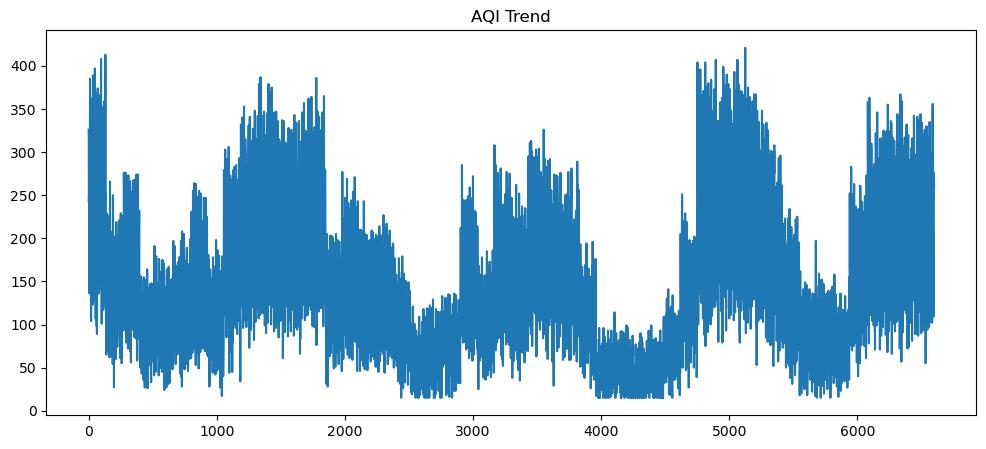

In [8]:
dataset['aqi'].plot(figsize=(12,5))

plt.title("AQI Trend")
plt.show()

In [9]:
dataset['date'] = pd.to_datetime(
    dataset['year'].astype(str) + '-' +
    dataset['month'].astype(str)
)

In [10]:
dataset[['year', 'month', 'date']].head()

,year,month,date
0,2015,1,2015-01-01
1,2015,2,2015-02-01
2,2015,3,2015-03-01
3,2015,4,2015-04-01
4,2015,5,2015-05-01


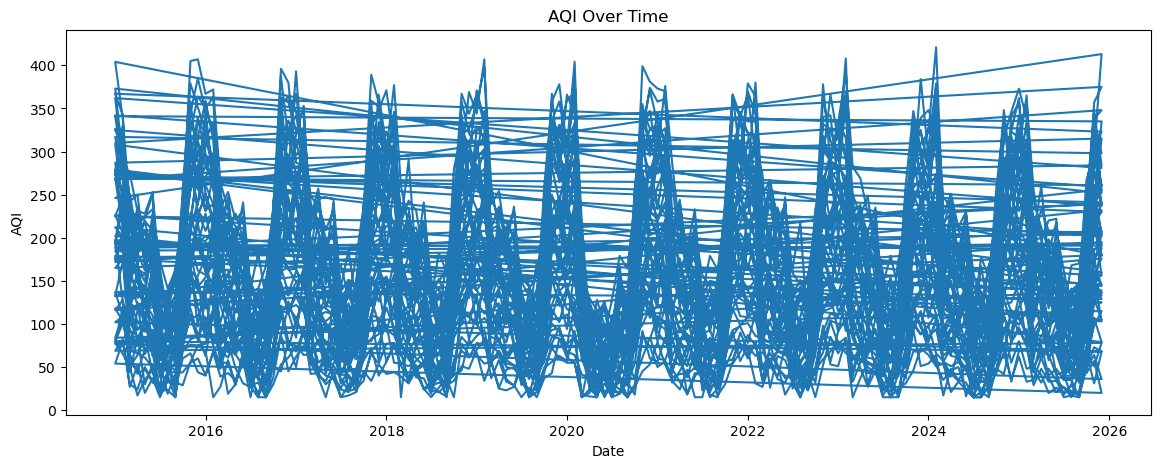

In [11]:
plt.figure(figsize=(14,5))

plt.plot(dataset['date'], dataset['aqi'])

plt.title("AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")

plt.show()

In [12]:
city_aqi = dataset.groupby('city')['aqi'].mean()

city_aqi.sort_values(ascending=False)

city
Delhi                 239.924242
Ghaziabad             237.772727
Faridabad             229.446970
Noida                 225.863636
Kanpur                222.840909
Gurugram              221.575758
Agra                  216.666667
Lucknow               208.189394
Varanasi              205.689394
Meerut                205.181818
Moradabad             204.659091
Bareilly              199.333333
Allahabad             198.310606
Patna                 196.901515
Gwalior               187.121212
Muzaffarpur           181.015152
Jaipur                173.484848
Jodhpur               168.507576
Kolkata               167.310606
Raipur                162.916667
Amritsar              156.121212
Jalandhar             156.060606
Ahmedabad             155.772727
Bhopal                152.553030
Chandigarh            148.674242
Ranchi                140.537879
Mumbai                139.674242
Siliguri              131.757576
Aurangabad            131.151515
Indore                127.704545
Nagpu

In [13]:
dataset.corr(numeric_only=True)

,latitude,longitude,population_million,year,month,aqi,pm25_ug_m3,pm10_ug_m3,no2_ug_m3,so2_ug_m3,...,humidity_pct,wind_speed_kmh,rainfall_mm,visibility_km,respiratory_admissions_per_100k,asthma_er_visits_per_100k,copd_cases_per_100k,cardiovascular_events_per_100k,premature_deaths_pollution,child_respiratory_infections_per_100k
latitude,1.000000e+00,1.104887e-01,-1.914373e-01,-1.537220e-13,-6.485962e-16,0.385773,0.359767,0.341885,0.351961,0.319083,...,0.003415,-0.004237,-0.043619,-0.295366,0.269268,0.235080,0.232462,0.246898,-0.006679,0.239843
longitude,1.104887e-01,1.000000e+00,-1.696047e-01,-5.652118e-14,1.543755e-16,-0.115535,-0.115682,-0.103187,-0.100247,-0.089408,...,0.022595,-0.000297,0.024493,0.101586,-0.077196,-0.067320,-0.074797,-0.080316,-0.098564,-0.059894
population_million,-1.914373e-01,-1.696047e-01,1.000000e+00,3.005853e-13,1.586076e-15,0.083197,0.086545,0.083422,0.077978,0.060066,...,-0.009539,-0.000776,0.003329,-0.075504,0.065035,0.054009,0.046774,0.059669,0.748373,0.064125
year,-1.537220e-13,-5.652118e-14,3.005853e-13,1.000000e+00,-1.911273e-16,-0.026817,-0.026291,-0.019768,-0.021725,-0.010030,...,-0.000361,0.000436,0.006082,0.022850,-0.006954,-0.005354,-0.007914,-0.006841,-0.000659,-0.012879
month,-6.485962e-16,1.543755e-16,1.586076e-15,-1.911273e-16,1.000000e+00,-0.056617,-0.044006,-0.045617,-0.048966,-0.051046,...,0.237187,-0.002664,0.193448,0.047485,-0.037008,-0.053370,-0.041066,-0.022026,-0.017193,-0.032016
aqi,3.857728e-01,-1.155350e-01,8.319653e-02,-2.681694e-02,-5.661665e-02,1.000000,0.946204,0.901986,0.900232,0.819950,...,-0.413262,0.001675,-0.298730,-0.766660,0.875019,0.770174,0.738669,0.646930,0.276506,0.771270
pm25_ug_m3,3.597670e-01,-1.156823e-01,8.654537e-02,-2.629055e-02,-4.400586e-02,0.946204,1.000000,0.952007,0.851830,0.773101,...,-0.387105,-0.001912,-0.280007,-0.727180,0.828662,0.726635,0.703812,0.607559,0.269511,0.731333
pm10_ug_m3,3.418852e-01,-1.031873e-01,8.342168e-02,-1.976829e-02,-4.561705e-02,0.901986,0.952007,1.000000,0.809119,0.737792,...,-0.372260,-0.004197,-0.269877,-0.693353,0.791930,0.698376,0.672662,0.577551,0.256452,0.696958
no2_ug_m3,3.519611e-01,-1.002472e-01,7.797817e-02,-2.172529e-02,-4.896604e-02,0.900232,0.851830,0.809119,1.000000,0.735479,...,-0.369970,0.007380,-0.269591,-0.690218,0.783810,0.694643,0.666755,0.586753,0.251052,0.690265
so2_ug_m3,3.190827e-01,-8.940765e-02,6.006600e-02,-1.003039e-02,-5.104570e-02,0.819950,0.773101,0.737792,0.735479,1.000000,...,-0.343166,0.007708,-0.251068,-0.630821,0.717426,0.628618,0.607204,0.530041,0.220959,0.623962


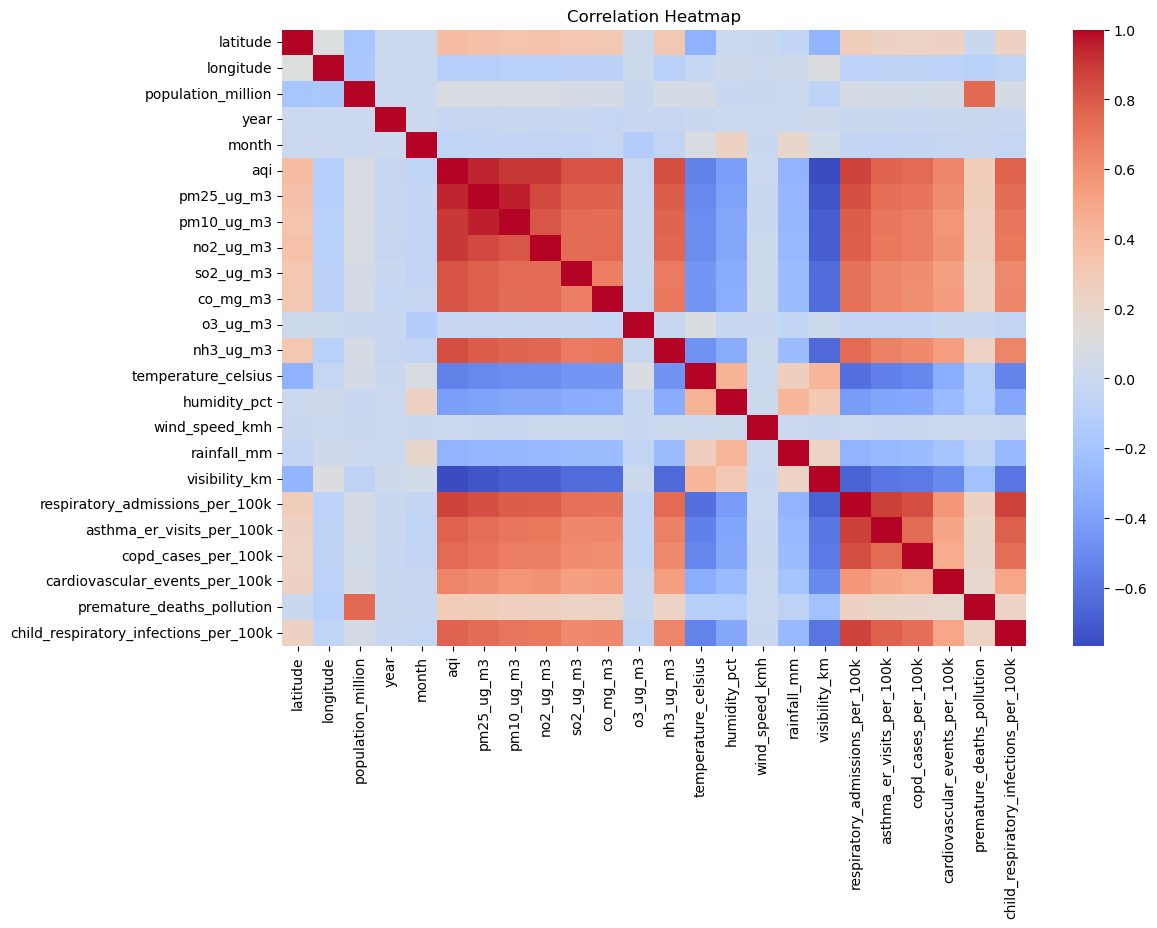

In [14]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    dataset.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()